In [4]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

In [5]:
ocr = PaddleOCR(det_model_dir='ppocr/ch_PP-OCRv3_det_infer',
                rec_model_dir='ppocr/ch_PP-OCRv3_rec_infer',
                cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/17 12:34:58] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='ppocr/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, fourie

209
[[('CANICES-3(B)/NMB-3(B)', 0.8905286192893982)]]
[[('CAN ICES-3 (B)/NMB-3(B)', 0.9218139052391052)]]
[[('CAN ICES-3 (B)/NMB-3(B)', 0.9376726746559143)]]


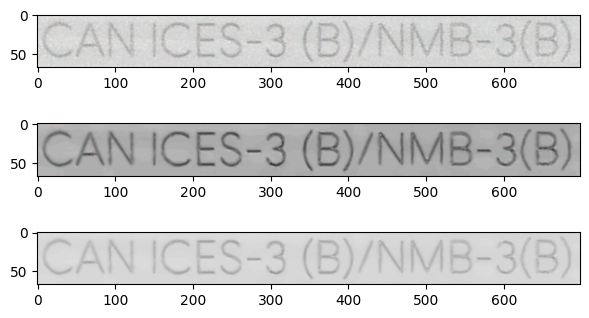

In [65]:
path = 'crops'

imgs = os.listdir(path)
img = random.choice(imgs)
img = cv2.imread(os.path.join(path,img))

dst = cv2.fastNlMeansDenoisingColored(img,None,3,3,7,21)

img2 = dst + dst

mean = np.mean(img).astype(np.uint8)
print(mean)

result1 = ocr.ocr(img,det=False,rec=True,cls=True)
print(result1)

result2 = ocr.ocr(img2,det=False,rec=True,cls=True)
print(result2)

result3 = ocr.ocr(dst,det=False,rec=True,cls=True)
print(result3)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7,4))
axes[0].imshow(img)
axes[1].imshow(img2)
axes[2].imshow(dst)

# references

[OPENCV: 'FAST' LIKE CORNER DETECTION WITH SCANNING WINDOW](http://dsynflo.blogspot.com/2014/07/opencv-fast-like-corner-detection-with.html)

[006 Morphological transformations with OpenCV in Python](https://datahacker.rs/006-morphological-transformations-with-opencv-in-python/)

[Morphological Transformations](https://docs.opencv.org/3.4/d4/d76/tutorial_js_morphological_ops.html)

[Image Denoising](https://docs.opencv.org/3.4/d5/d69/tutorial_py_non_local_means.html)

[Basics of Brute-Force Matcher](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)